# Lab 5: Disparity Map and 3D Reconstruction

In this lab, you'll learn how to create a **disparity map** from a pair of rectified stereo images and then reconstruct a 3D point cloud from that disparity map. The tasks include loading and visualizing stereo images, computing a disparity map using OpenCV, and converting the disparity to 3D coordinates. We also explore visualizing the 3D point cloud and analyzing the disparity values.

A key concept in stereo vision is that **disparity** (the horizontal shift between corresponding points in two images) is inversely proportional to **depth** — closer objects have larger disparities, while farther objects have smaller disparities. The relationship between depth $Z$, focal length $f$, baseline $B$ (distance between camera centers), and disparity $d$ for a point in standard stereo geometry is:

$$Z = \frac{f \cdot B}{d}$$

We'll work in pixel units for simplicity and use the given focal length $f = 0.08 \times 2000$ pixels and baseline $B = 0.4 \times 2000$ pixels.

## Background

### Anaglyph Stereo Visualization
A quick way to visually inspect stereo images is to create a **red–cyan anaglyph**. The idea is to filter the left image to keep only its red channel and filter the right image to keep only its green and blue channels (cyan), then add the results. When viewed through red–cyan glasses, each eye sees only one of the two images, producing a 3D effect.

### Disparity and Depth
Computing the disparity map is typically done with **block matching** algorithms. OpenCV provides the `StereoBM` and `StereoSGBM` classes, which implement block matching and semi-global block matching, respectively. These compute a per-pixel disparity image by comparing small windows in the left and right images.

OpenCV's block matching parameters like `numDisparities` (the maximum disparity range) and `blockSize` (matching window size) significantly influence the result. After computing disparity, the depth (distance from the camera) can be recovered using the relation $Z = f \cdot B / d$. 

Further, individual 3D coordinates $(X,Y,Z)$ of each pixel can be computed using the pinhole model:

$$X = \frac{(u - c_x) \cdot Z}{f}, \quad Y = \frac{(v - c_y) \cdot Z}{f}, \quad Z = \frac{f \cdot B}{d}$$

where $(u,v)$ is the pixel coordinate, $(c_x, c_y)$ is the principal point (usually the center of the image), $f$ is the focal length, $B$ is the baseline, and $d$ is the disparity.

In [ ]:
%matplotlib inline
from pathlib import Path

import numpy as np
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

import open3d as o3d

# Configure plotting
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.labelsize": 11,
        "axes.titlesize": 12,
    }
)


In [2]:
# Data directory configuration
ROOT_DIR = (Path.cwd().parent).resolve()
assert ROOT_DIR.exists(), f"Root directory does not exist: {ROOT_DIR}"
LV5_DIR = ROOT_DIR / ".data/LV_5"

list(LV5_DIR.glob("*.jpg"))


[PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_5/scene_l.jpg'),
 PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_5/scene_r.jpg')]

## 1. Load and Preprocess the Stereo Images

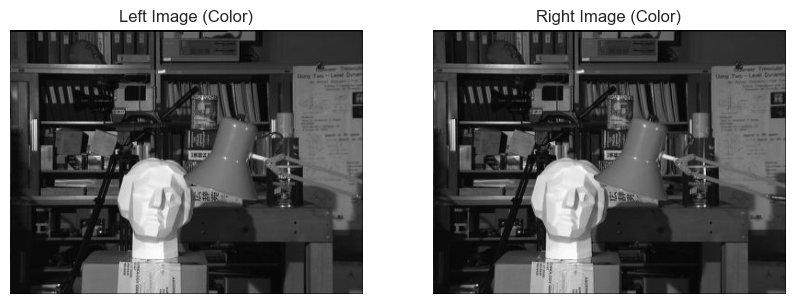

In [3]:
# TODO: Replace with the actual paths to your rectified stereo images
left_img_path = LV5_DIR / "scene_l.jpg"
right_img_path = LV5_DIR / "scene_r.jpg"

left_color = cv2.imread(left_img_path.as_posix())
right_color = cv2.imread(right_img_path.as_posix())

left_gray = cv2.cvtColor(left_color, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_color, cv2.COLOR_BGR2GRAY)

_, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(left_color, cv2.COLOR_BGR2RGB))
axes[0].set_title("Left Image (Color)")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(right_color, cv2.COLOR_BGR2RGB))
axes[1].set_title("Right Image (Color)")
axes[1].axis("off")
plt.show()


## 2. Create a Red–Cyan Anaglyph Visualization

Anaglyph images fuse two views into one viszalization by encoding one view in the red channel and the other view in the green+blue channels (cyan). This allows the human brain to perceive 3D features of the scene, when viewing the anaglyph through "color-coded" glasses [Wikipedia](https://en.wikipedia.org/wiki/Anaglyph_3D?utm_source=chatgpt.com).


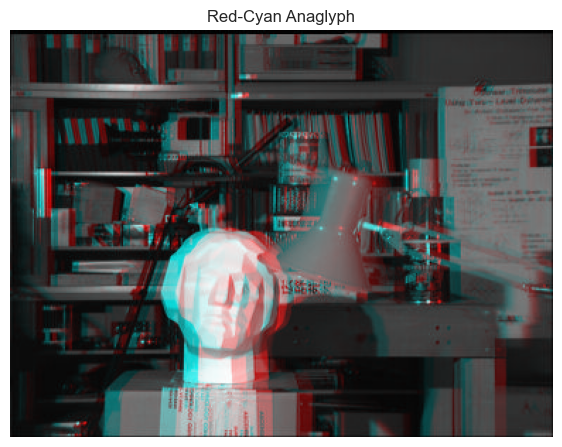

In [4]:
# Split color channels
left_b, left_g, left_r = cv2.split(left_color)
right_b, right_g, right_r = cv2.split(right_color)

# Form a red–cyan anaglyph: red from left image, green and blue from right image
anaglyph = cv2.merge((right_b, right_g, left_r))

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(anaglyph, cv2.COLOR_BGR2RGB))
plt.title("Red-Cyan Anaglyph")
plt.axis("off")
plt.show()


## 3. Compute the Disparity Map

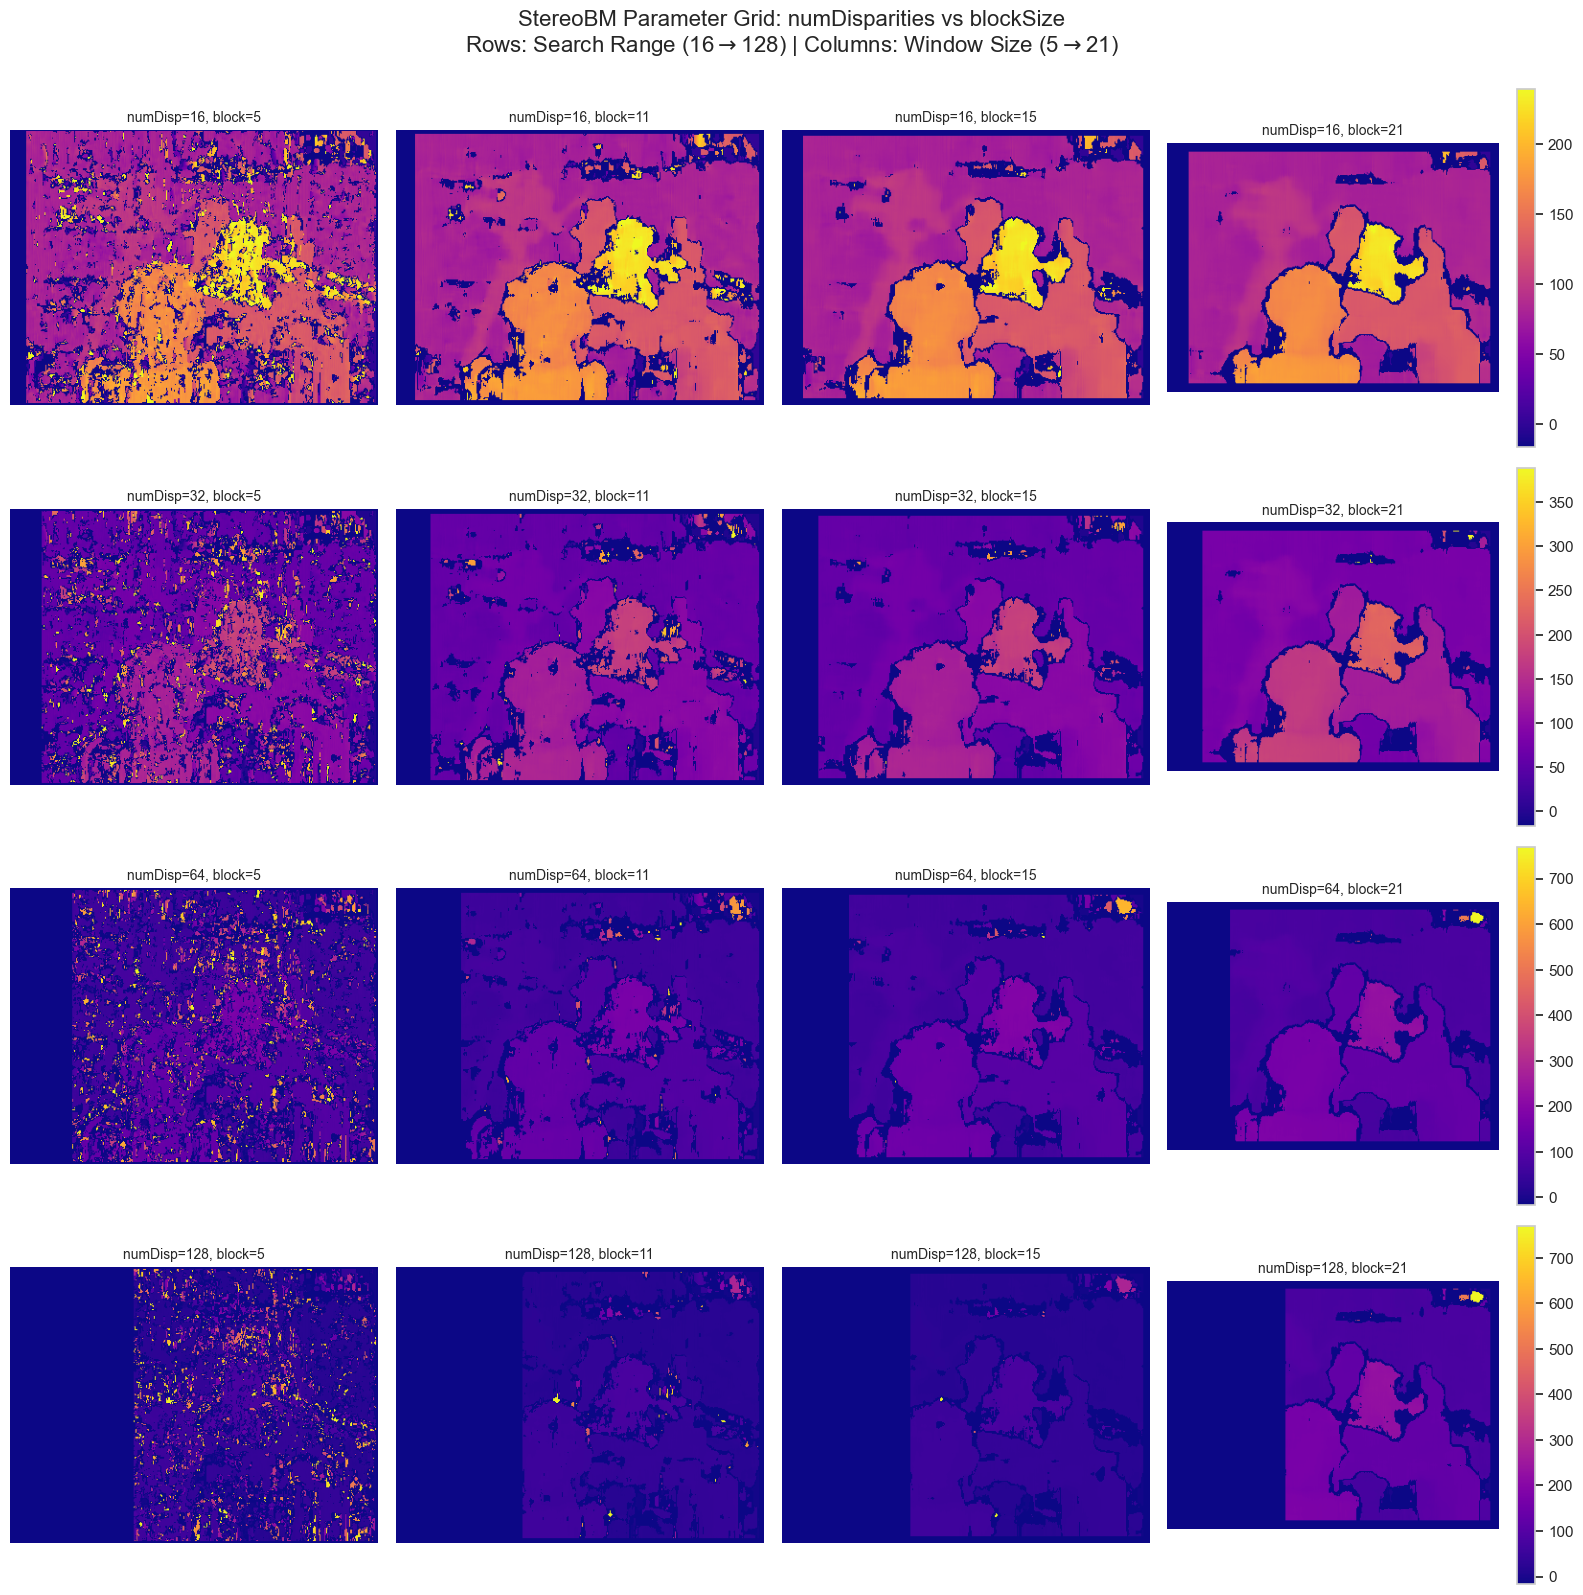

In [5]:
# Parameter combinations to test (4x4 grid = 16 combinations)
param_grid = {
    # num_disparities: Maximum search range for matching (must be divisible by 16)
    # -> Smaller values (16-32): Good for close objects, faster computation, limited depth range
    # -> Larger values (64-128): Captures distant objects, wider depth range, slower computation, larger "dead-zone"
    "num_disparities": [16, 32, 64, 128],
    # block_size: Size of the matching window (must be odd)
    # -> Smaller values (5-11): Preserves fine details, more noise, sensitive to texture
    # -> Larger values (15-21): Smoother results, less noise, loses fine details
    "block_size": [5, 11, 15, 21],
}

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle(
    "StereoBM Parameter Grid: numDisparities vs blockSize\n"
    r"Rows: Search Range (16$\rightarrow$128) | Columns: Window Size (5$\rightarrow$21)",
    fontsize=16,
    y=0.997,
)

for i, num_disp in enumerate(param_grid["num_disparities"]):
    for j, block_sz in enumerate(param_grid["block_size"]):
        # Create StereoBM with current parameters
        stereo = cv2.StereoBM_create(numDisparities=num_disp, blockSize=block_sz)

        # Compute disparity
        disp = stereo.compute(left_gray, right_gray)

        ax = axes[i, j]
        im = ax.imshow(disp, cmap="plasma")
        ax.set_title(f"numDisp={num_disp}, block={block_sz}", fontsize=10)
        ax.axis(False)

        # Add colorbar to rightmost column
        if j == 3:
            plt.colorbar(im, ax=ax, fraction=0.05, pad=0.05)

plt.tight_layout()
plt.show()


`numDisparities` = 16 and `blockSize`= 15...21 seem to yield the best compromise in terms of:
- relatively smooth surfaces
- low freckle noise
- slim dead-zone / invalid disparity region
- clearest dynamic range (if this is a valid indicator)

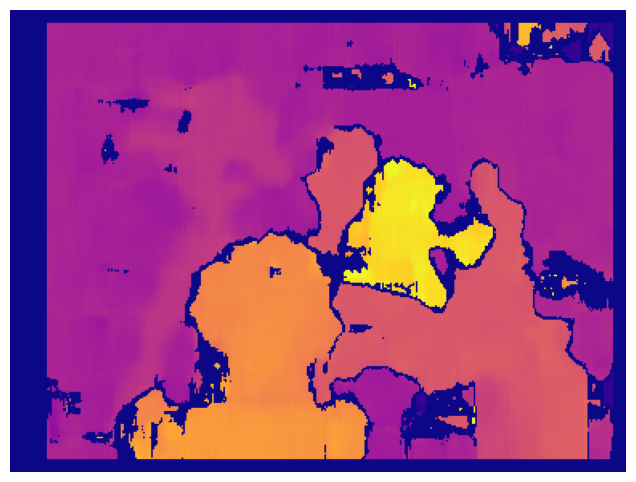

In [44]:
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=17)

disp = stereo.compute(left_gray, right_gray)

plt.imshow(disp, cmap="plasma")
plt.axis(False)
plt.show()


### Visual Inspection Guide

Look for the subplot that best balances:

- **Detail preservation**: Can you see object boundaries and textures clearly?  
- **Low noise**: Are there random speckles, holes, or artifacts?  
- **Depth coverage**: Do both near and far objects have valid disparity values?

**What to avoid:**
- Too much noise → Increase `blockSize` or `uniquenessRatio`
- Missing depth information → Increase `numDisparities`
- Too blurry → Decrease `blockSize`

## 4. Reconstruct the 3D Point Cloud

The depth $Z$ is computed using $Z = f \cdot B / d$. Once $Z$ is known, the $X$ and $Y$ coordinates are computed from the pixel positions $(u,v)$ relative to the principal point $(c_x, c_y)$:

$$X = \frac{(u - c_x) \cdot Z}{f}, \quad Y = \frac{(v - c_y) \cdot Z}{f}, \quad Z = \frac{f \cdot B}{d}$$

We will use the provided focal length $f = 0.08 \times 2000$ pixels and baseline $B = 0.4 \times 2000$ pixels. The principal point $(c_x, c_y)$ is assumed to be the center of the image.

After computing $X$, $Y$, and $Z$, we'll filter out points with invalid or non-positive disparity and optionally restrict the cloud to a region of interest.

In [45]:
f = 0.08 * 2000  # focal length in px
B = 0.4 * 2000  # baseline in px

# Image dimensions
height, width = disp.shape
# Principal point (assume image center)
cx = width / 2.0
cy = height / 2.0

K = np.array(
    [
        [f, 0, cx],
        [0, f, cy],
        [0, 0, 1],
    ]
)


In [46]:
# filter - disp contains -16 for invalid pxs, avoid div by zero
valid_mask = disp > 0

# Create 2D image grid
v, u = np.mgrid[0:height, 0:width].astype(np.float32)

# Compute 3D coordinates from disparity
Z = np.zeros_like(disp, dtype=np.float32)
Z[valid_mask] = (f * B) / disp[valid_mask]

X = (u - cx) * Z / f
Y = (v - cy) * Z / f

pc = np.stack(
    [X[valid_mask], Y[valid_mask], Z[valid_mask], left_gray[valid_mask]], axis=-1
)

# Display a summary of the point cloud
print(f"""
#PC shape: {pc.shape}
# mean(PC): {np.mean(pc, axis=0)}
# min(PC): {np.min(pc, axis=0)}
# max(PC): {np.max(pc, axis=0)}
""")



#PC shape: (85050, 4)
# mean(PC): [ -26.968071 -106.84234  1317.2528     72.64995 ]
# min(PC): [-12800.      -7733.3335    533.3333      0.    ]
# max(PC): [ 7866.667  9422.223 14222.223   255.   ]



In [47]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pc[:, 0],
            y=pc[:, 1],
            z=pc[:, 2],
            mode="markers",
            marker=dict(size=1, color=pc[:, 3], colorscale="Viridis", opacity=0.8),
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",  # keep aspect ratio based on data
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    title="3D Point Cloud",
)

fig.show()


In [48]:
pc_o3d = o3d.geometry.PointCloud()
pc_o3d.points = o3d.utility.Vector3dVector(pc[:, :3])

pc_filtered, valid = pc_o3d.remove_statistical_outlier(
    nb_neighbors=20,  # number of neighbors to analyze per point
    std_ratio=2.0,  # threshold: lower = stricter filtering
)
pc_filtered = np.array(pc_filtered.points)


In [49]:
print(f"# Outliers: {len(pc) - len(pc_filtered)}")
len(valid), len(pc)

mask = np.zeros(len(pc[:, 3]), dtype=bool)
mask[valid] = True
colors_filtered = pc[:, 3][mask]


# Outliers: 42


In [50]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pc_filtered[:, 0],
            y=pc_filtered[:, 1],
            z=pc_filtered[:, 2],
            mode="markers",
            marker=dict(size=1, opacity=0.8, color=colors_filtered),
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",  # keep aspect ratio based on data
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    title="3D Point Cloud",
)

fig.show()


3D reconstruction with `numDisparities` = 16 and `blockSize`= 15:
![Reconstruction after outlier removal](../figures/lv5_recon_16-15.png)

3D reconstruction with `numDisparities` = 16 and `blockSize`= 17:

![Reconstruction after outlier removal](../figures/lv5_recon_16-17.png)

3D reconstruction with `numDisparities` = 16 and `blockSize`= 21:
![Reconstruction after outlier removal](../figures/lv5_recon_16-21.png)